In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
rng = np.random.default_rng(42)

# House size and price, both measured in thousands.
X_train = np.linspace(0.5, 3.5, 50)
y_train = 200 * X_train + 100 + rng.normal(0, 65, size=X_train.shape)

In [17]:
def cost_function(X, y, w, b):
    predictions = w * X + b
    return np.mean((predictions - y) ** 2) / 2

In [18]:
def predict(X, w, b):
    return w * X + b

In [19]:
def gradient_descent(X, y, learning_rate=0.01, iterations=500):
    w = 0.0
    b = 0.0
    cost_history = []
    w_and_b_history = []

    # X contains m training examples, so its shape is (m,).
    m = X.shape[0]

    for _ in range(iterations):
        error = predict(X, w, b) - y
        dw = np.dot(error, X) / m
        db = np.sum(error) / m

        w -= learning_rate * dw
        b -= learning_rate * db

        cost_history.append(cost_function(X, y, w, b))
        w_and_b_history.append((w, b))

    return w, b, np.array(cost_history), np.array(w_and_b_history)

In [20]:
w, b, cost_history, w_and_b_history = gradient_descent(X_train, y_train)
predictions = predict(X_train, w, b)

print(f"w = {w}, b = {b}")

w = 209.0625791067006, b = 88.04070999380137


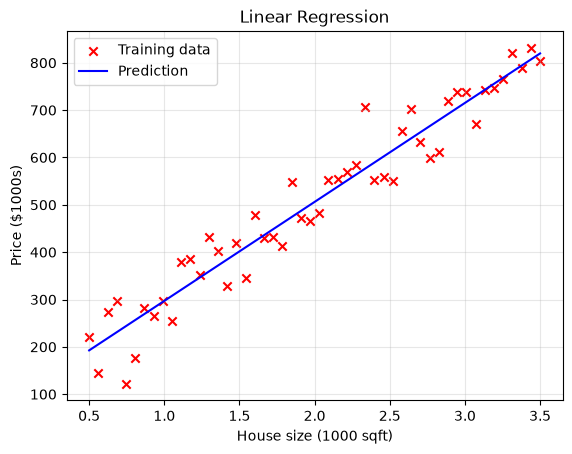

In [21]:
plt.scatter(X_train, y_train, marker='x', color='red', label='Training data')
plt.plot(X_train, predictions, color='blue', label='Prediction')
plt.title('Linear Regression')
plt.xlabel('House size (1000 sqft)')
plt.ylabel('Price ($1000s)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

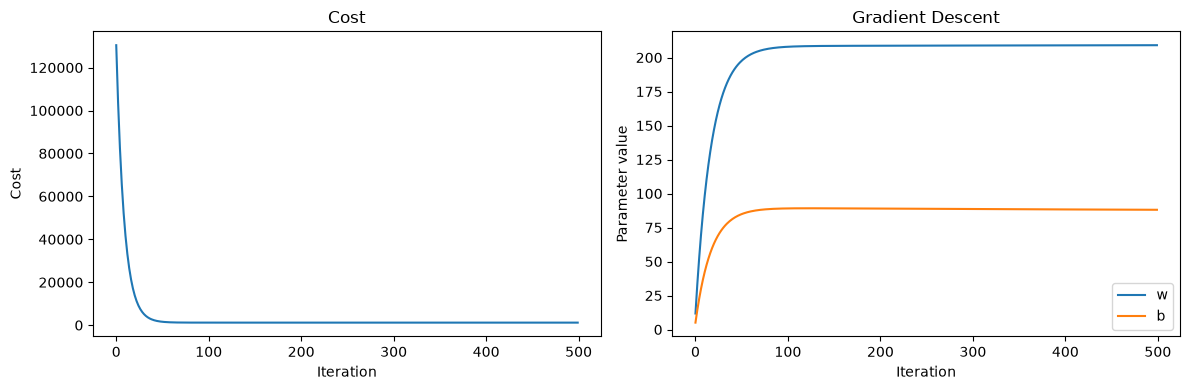

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(cost_history)
ax1.set_title('Cost')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cost')

ax2.plot(w_and_b_history[:, 0], label='w')
ax2.plot(w_and_b_history[:, 1], label='b')
ax2.set_title('Gradient Descent')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Parameter value')
ax2.legend()

plt.tight_layout()
plt.show()